# Glaciers — GLIMS outlines & WGMS mass balance (live)

Beyond the RGI snapshot, the backend reaches two more open sources:

- **GLIMS** — *time-series* glacier outlines, queried by bounding box through the GLIMS WFS (a glacier can have several outlines from different dates).
- **WGMS** — the *Fluctuations of Glaciers* database: mass balance, front variation (length change), and glacier state, as tidy tables.

This notebook draws GLIMS outlines for an Alpine box and plots a glacier's measured mass balance over time.

## Setup

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt

from earthlens.core import EarthLens

workdir = Path(tempfile.mkdtemp(prefix='glaciers-'))

## GLIMS — time-series outlines by bounding box

Use `data_source='glims'` with a bounding box. `max_features=` caps the number of outlines returned by the WFS. The result is a `FeatureCollection` in EPSG:4326.

In [2]:
glims = EarthLens(
    data_source='glims',
    variables=['glims:outlines'],
    lat_lim=[45.9, 46.05],
    lon_lim=[7.0, 7.2],
    max_features=300,
    path=workdir,
).download()

len(glims), str(glims.crs)

2026-06-28 17:55:13 | INFO | pyramids.base.config | Logging is configured.


2026-06-28 17:55:17.290 | INFO     | earthlens.glaciers.backend:_log_citation:442 - Glaciers source citation: GLIMS and NSIDC (2005, updated current year), Global Land Ice Measurements from Space glacier database, NSIDC-0272 (CC-BY-4.0); cite the contributing analysts.


2026-06-28 17:55:17.291 | INFO     | earthlens.glaciers.backend:download:392 - Glaciers glims:outlines: returned a FeatureCollection (289 outline(s)).


(289, 'EPSG:4326')

GLIMS is multi-temporal: the `src_date` column shows that the same glacier can appear with outlines from different acquisition dates.

In [3]:
glims[['glac_id', 'glac_name', 'src_date']].head()

,glac_id,glac_name,src_date
11,G006984E45950N,du Tour Noir,2022-08-12 00:00:00+00:00
12,G006984E45950N,du Tour Noir,2022-08-12 00:00:00+00:00
13,G006984E45950N,du Tour Noir,2022-08-12 00:00:00+00:00
14,G006984E45950N,du Tour Noir,2022-08-12 00:00:00+00:00
15,G006984E45950N,du Tour Noir,2022-08-12 00:00:00+00:00


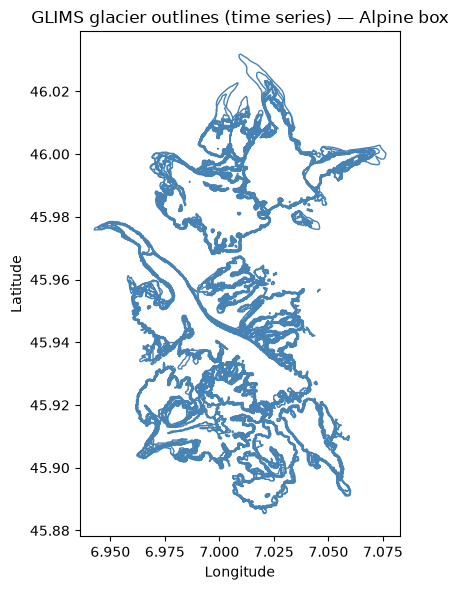

In [4]:
ax = glims.plot(figsize=(8, 6), facecolor='none', edgecolor='steelblue')
ax.set_title('GLIMS glacier outlines (time series) — Alpine box')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## WGMS — a glacier's mass-balance record

Now the tabular side. `data_source='wgms'` with `variables=['wgms:mass_balance']` returns a `DataFrame`. The first call downloads and caches the Fluctuations of Glaciers archive (~37 MB) once. We filter to the famous **Aletsch** glacier by name.

In [5]:
df = EarthLens(
    data_source='wgms',
    variables=['wgms:mass_balance'],
    glacier_name='aletsch',
    path=workdir,
).download()

df[['glacier_name', 'year', 'annual_balance']].dropna().head()

2026-06-28 17:55:22.007 | INFO     | earthlens.glaciers.backend:_log_citation:442 - Glaciers source citation: WGMS (2026), Fluctuations of Glaciers Database, DOI 10.5904/wgms-fog-2026-02-10.


2026-06-28 17:55:22.012 | INFO     | earthlens.glaciers.backend:download:400 - Glaciers wgms:mass_balance: 66 row(s) written to C:\Users\main\AppData\Local\Temp\glaciers-0ki13_ri\wgms_mass_balance.csv.


,glacier_name,year,annual_balance
0,GROSSER ALETSCH,1940,0.897
1,GROSSER ALETSCH,1941,-0.919
2,GROSSER ALETSCH,1942,-1.323
3,GROSSER ALETSCH,1943,-1.203
4,GROSSER ALETSCH,1944,-1.316


The `annual_balance` column is the net mass balance in millimetres water equivalent — negative years mean the glacier lost mass. Let's plot the record over time for the longest-running series in the selection.

In [6]:
series = df.dropna(subset=['annual_balance']).copy()
top = series['glacier_name'].value_counts().index[0]
one = series[series['glacier_name'] == top].sort_values('year')
top, len(one)

('GROSSER ALETSCH', 66)

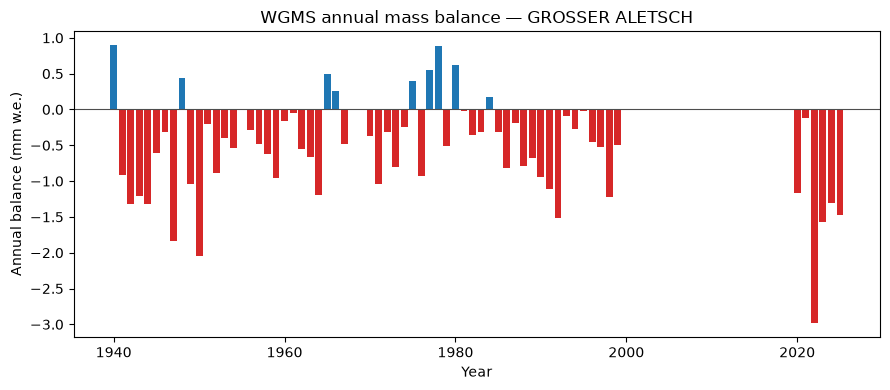

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in one['annual_balance']]
ax.bar(one['year'], one['annual_balance'], color=colors)
ax.axhline(0, color='0.3', linewidth=0.8)
ax.set_title(f'WGMS annual mass balance — {top}')
ax.set_xlabel('Year')
ax.set_ylabel('Annual balance (mm w.e.)')
plt.tight_layout()
plt.show()

The predominance of red (negative) bars in recent decades is the measured signature of sustained glacier mass loss.

## Takeaway

GLIMS gives you dated outlines for change studies; WGMS gives you the in-situ measurement record. Both come through the same `EarthLens(...).download()` call — the output shape follows the dataset. See the [usage guide](../../reference/glaciers/usage.md) for the full list of selectors.